# Zomato Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data=pd.read_csv('Zomato data .csv')
data

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [14]:
data.head(10)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
5,Timepass Dinner,Yes,No,3.8/5,286,600,Buffet
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6/5,8,800,Buffet
7,Onesta,Yes,Yes,4.6/5,2556,600,Cafes
8,Penthouse Cafe,Yes,No,4.0/5,324,700,other
9,Smacznego,Yes,No,4.2/5,504,550,Cafes


# Data cleaning

In [29]:
# convert the data type 
def handleRate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)
data['rate']=data['rate'].apply(handleRate)


In [31]:
 data.head(10)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
5,Timepass Dinner,Yes,No,3.8,286,600,Buffet
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6,8,800,Buffet
7,Onesta,Yes,Yes,4.6,2556,600,Cafes
8,Penthouse Cafe,Yes,No,4.0,324,700,other
9,Smacznego,Yes,No,4.2,504,550,Cafes


In [33]:
# check null 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0.5, 0, 'Type of Restaurant')

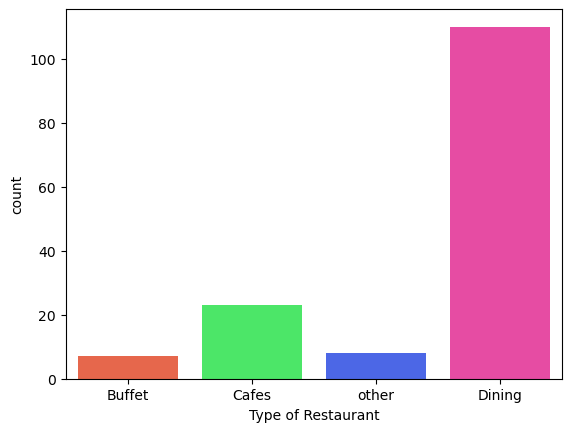

In [41]:
 
 sns.countplot(data=data, x='listed_in(type)', hue='listed_in(type)', palette=['#FF5733', '#33FF57', '#3357FF', '#FF33A6'], legend=False)

plt.xlabel("Type of Restaurant")

# Above graph  conclusion--------> majority of the resturant falls in dinning category

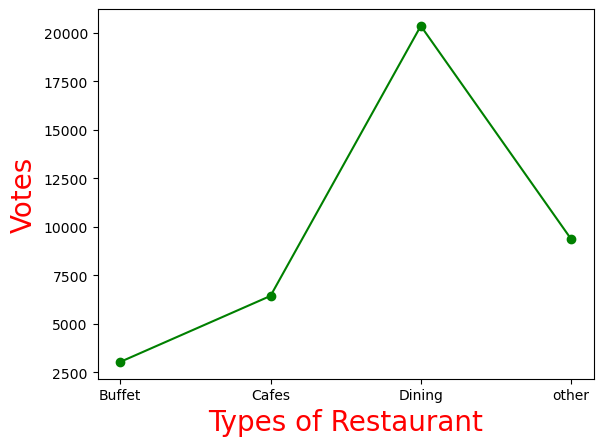

In [56]:
df = data.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': df})

# Plotting with a valid marker style (e.g., 'o' for circles)
plt.plot(result, color="green", marker="o")

# Adding labels for the axes
plt.xlabel("Types of Restaurant", color="red", size=20)
plt.ylabel("Votes", color="red", size=20)

# Display the plot
plt.show()


 # Above graph conclusion-->Dinning resturants has recieved  maximum votes 

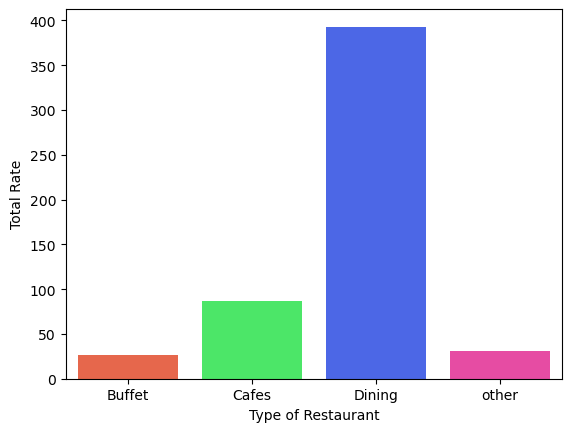

In [66]:
 import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Summing the votes for each type of restaurant
df = data.groupby('listed_in(type)')['rate'].sum().reset_index()

# Plotting the summed votes
sns.barplot(data=df, x='listed_in(type)', y='rate',hue='listed_in(type)', palette=['#FF5733', '#33FF57', '#3357FF', '#FF33A6'])

# Adding labels
plt.xlabel("Type of Restaurant")
plt.ylabel("Total Rate")

# Display the plot
plt.show()


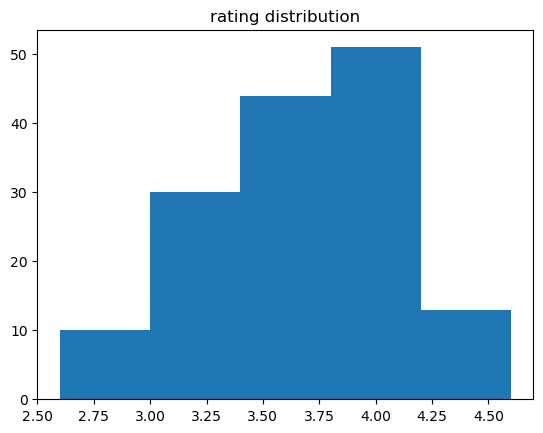

In [68]:
plt.hist(data['rate'],bins=5)
plt.title("rating distribution")
plt.show()


# conclusion-->Maximum rating is between 3.5 to 4

In [73]:
data.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

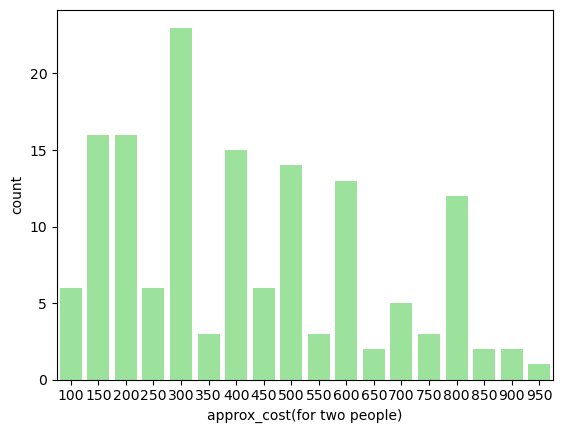

In [114]:
coupleData = data['approx_cost(for two people)'.strip()]
sns.countplot(x=coupleData,color="lightgreen")

# conclusion from above graph is that the majority of couples preferr resturants with appox.cost of RS 300

<Axes: xlabel='online_order', ylabel='rate'>

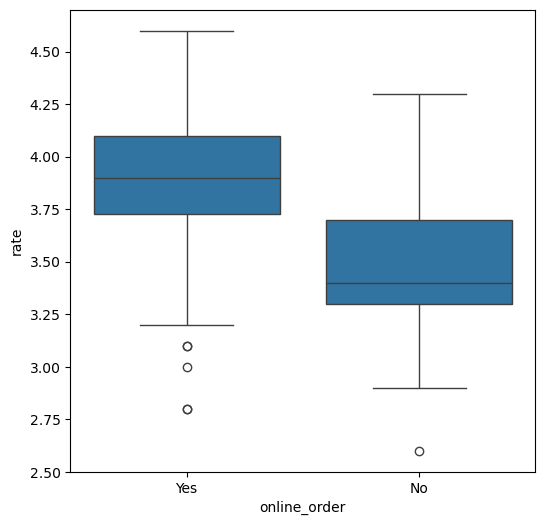

In [117]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rate',data=data)

# conclusion from above graph is that offline order receive low rating as compared to online order

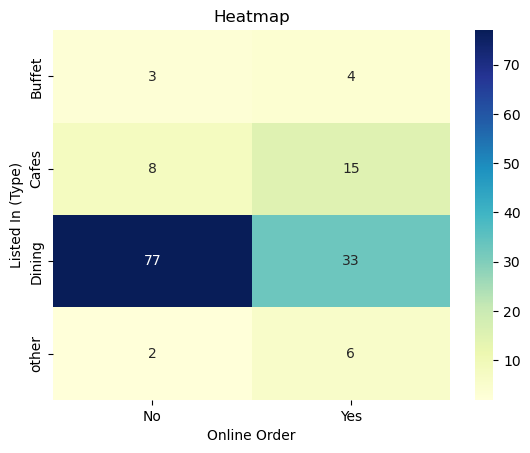

In [122]:
pivot_table = data.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")
plt.show()


# conclusion from above graph is that offline order is more as compared online

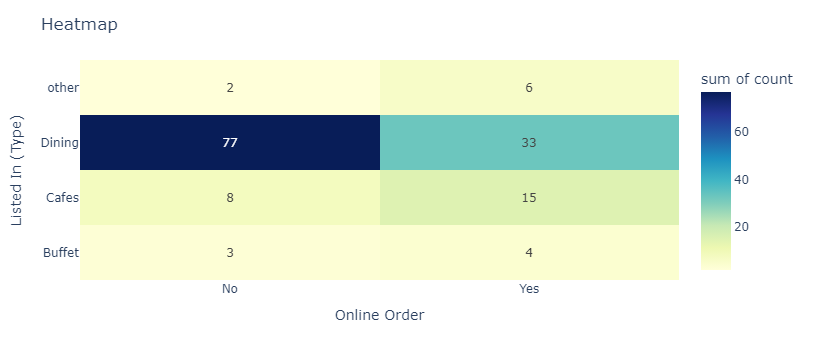

In [127]:
import plotly.express as px
# Create the pivot table
pivot_table = data.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)

# Convert the pivot table to a DataFrame for Plotly
pivot_df = pivot_table.reset_index()

# Melt the DataFrame for Plotly
pivot_melted = pivot_df.melt(id_vars='listed_in(type)', var_name='online_order', value_name='count')

# Create the heatmap using Plotly Express
fig = px.density_heatmap(pivot_melted, x='online_order', y='listed_in(type)', z='count', 
                         color_continuous_scale="YlGnBu", text_auto=True)

# Add title and labels
fig.update_layout(title='Heatmap', xaxis_title='Online Order', yaxis_title='Listed In (Type)')

# Show the figure
fig.show()
